In [82]:
import sys

print("Python executable:")
print(sys.executable)

Python executable:
/workspaces/Hand-written-digit-recognition/.venv/bin/python


# 1. Project Setup and Dataset Inspection

This section prepares the project environment and inspects the handwritten digit dataset before model training.

The training dataset contains handwritten digit images organized into folders `0`–`9`, where each folder represents the true digit class.

Before building the classification model, we will:

- define the project data paths,
- inspect the number of images in each class,
- check the original dimensions of all images,
- identify images that are not already `28 × 28` pixels.

Images with different dimensions will be retained because they are valid training observations. They will be standardized later during image preprocessing.

In [83]:
import sys

print("Python:", sys.executable)

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("All imports successful!")

Python: /workspaces/Hand-written-digit-recognition/.venv/bin/python
OpenCV: 5.0.0
NumPy: 2.5.3
Pandas: 3.0.6
All imports successful!


In [84]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [85]:
DATA_DIR = Path("data")
TEST_DIR = DATA_DIR / "test"

print("Data directory:", DATA_DIR.resolve())
print("Data exists:", DATA_DIR.exists())
print("Professor test directory exists:", TEST_DIR.exists())

Data directory: /workspaces/Hand-written-digit-recognition/data
Data exists: True
Professor test directory exists: True


## 1.1 Inspect Original Image Dimensions

The professor's baseline model ultimately converts every input image to `28 × 28` pixels.

However, some images in the supplied dataset have larger original resolutions. Before applying any transformation, we inspect the original width and height of every image.

This allows us to understand the amount of preprocessing required without deleting valid observations.

In [86]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg"}

records = []

for digit in range(10):
    digit_dir = DATA_DIR / str(digit)

    for image_path in sorted(digit_dir.iterdir()):

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        image = cv2.imread(
            str(image_path),
            cv2.IMREAD_GRAYSCALE
        )

        if image is None:
            print(f"Could not read: {image_path}")
            continue

        height, width = image.shape

        records.append({
            "digit": digit,
            "filename": image_path.name,
            "width": width,
            "height": height,
            "is_28x28": width == 28 and height == 28
        })

image_sizes = pd.DataFrame(records)

image_sizes.head()

,digit,filename,width,height,is_28x28
0,0,6620412001_0.png,28,28,True
1,0,6710422031_0.png,28,28,True
2,0,6720422021_00.png,1317,878,False
3,0,6810413002_0.png,28,28,True
4,0,6820412001.jpg,28,28,True


In [87]:
# Dataset Summary

total_images = len(image_sizes)
images_28x28 = image_sizes["is_28x28"].sum()
non_28_images = (~image_sizes["is_28x28"]).sum()

print(f"Total images: {total_images}")
print(f"28x28 images: {images_28x28}")
print(f"Non-28x28 images: {non_28_images}")
print(f"Non-28x28 percentage: {non_28_images / total_images:.2%}")

Total images: 340
28x28 images: 284
Non-28x28 images: 56
Non-28x28 percentage: 16.47%


In [88]:
# Class Distribution

class_distribution = (
    image_sizes
    .groupby("digit")
    .size()
    .rename("n_images")
)

class_distribution

digit
0    34
1    35
2    35
3    34
4    34
5    34
6    34
7    33
8    33
9    34
Name: n_images, dtype: int64

In [89]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from skimage.feature import hog


# Project paths
DATA_DIR = Path("data")
VALIDATION_DIR = DATA_DIR / "unseen_validation"
FINAL_TEST_DIR = DATA_DIR / "final_test"

print("Data directory:", DATA_DIR.resolve())
print("Data exists:", DATA_DIR.exists())
print("Validation exists:", VALIDATION_DIR.exists())
print("Final test exists:", FINAL_TEST_DIR.exists())

Data directory: /workspaces/Hand-written-digit-recognition/data
Data exists: True
Validation exists: False
Final test exists: False


#### Show only non-28×28 images

In [90]:
non_28x28_images = image_sizes[
    ~image_sizes["is_28x28"]
]

non_28x28_images

,digit,filename,width,height,is_28x28
2,0,6720422021_00.png,1317,878,False
5,0,6820412002_0.jpg,1000,1223,False
12,0,6820422011_0.png,1536,690,False
13,0,6820422012_0.png,2736,1604,False
18,0,6820422018_0.png,1152,648,False
22,0,6820422024_0.png,1152,720,False
37,1,6720422021_01.png,1317,878,False
40,1,6820412002_1.jpg,1000,1119,False
48,1,6820422011_1.png,1536,1138,False
49,1,6820422012_1.png,2736,1604,False


## 1.2 Dataset Inspection Findings

The dataset contains **340 handwritten digit images** across 10 classes (`0`–`9`).

- **284 images (83.53%)** are already `28 × 28` pixels.
- **56 images (16.47%)** have different original dimensions.
- Each digit class contains approximately **33–35 images**.

The dataset is therefore approximately balanced across classes.

The images with different resolutions will not be removed because they are valid handwritten digit observations. Removing them would reduce the available training data and handwriting variation.

For the baseline experiment, all images will be resized directly to `28 × 28` pixels to reproduce the professor's original approach.

Later experiments will investigate improved preprocessing methods to reduce distortion and improve classification performance.

# 2. Build the Baseline Dataset and Create the Train-Test Split

This section prepares the handwritten digit images for the baseline classification model.

To reproduce the professor's original preprocessing approach:

1. Read each image in grayscale.
2. Resize every image directly to `28 × 28` pixels.
3. Flatten the image into `784` pixel features.
4. Use the folder name (`0`–`9`) as the target class.

No additional preprocessing or data augmentation is applied in this section.

After constructing the dataset, the data will be divided into:

- **80% training data**
- **20% testing data**

A stratified split is used so that the proportion of each digit class is maintained in both sets.

The same train-test split will be reused across later experiments so that model improvements can be compared fairly.

In [91]:
X = []
y = []
image_paths = []

for digit in range(10):
    digit_dir = DATA_DIR / str(digit)

    for image_path in sorted(digit_dir.iterdir()):

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        # Read image in grayscale
        image = cv2.imread(
            str(image_path),
            cv2.IMREAD_GRAYSCALE
        )

        if image is None:
            print(f"Could not read: {image_path}")
            continue

        # Professor baseline:
        # resize every image directly to 28x28
        image = cv2.resize(
            image,
            (28, 28)
        )

        # Convert 28x28 image into 784 features
        pixels = image.flatten()

        X.append(pixels)
        y.append(digit)
        image_paths.append(image_path)

# Convert Python lists to NumPy arrays
X = np.asarray(X)
y = np.asarray(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (340, 784)
y shape: (340,)


## 2.1 Baseline Feature Representation

Each image is represented by `784` grayscale pixel values.

Because no normalization has been applied yet, pixel intensity values remain approximately in the range:

\[
0 \leq x_j \leq 255
\]

where darker and lighter pixels are represented by different intensity values.

This raw-pixel representation will serve as the baseline. Pixel normalization will be tested later as a separate experiment.

In [92]:
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())
print("Data type:", X.dtype)

Minimum pixel value: 0
Maximum pixel value: 255
Data type: uint8


In [93]:
# Create the 80/20 Stratified Split

from sklearn.model_selection import train_test_split

# Keep indices so the exact same samples can be reused
# in every later experiment.
indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (272, 784)
X_test shape : (68, 784)
y_train shape: (272,)
y_test shape : (68,)


## 2.2 Verify Class Distribution After Splitting

Stratified sampling is used to preserve the class distribution of digits `0`–`9`.

Since the full dataset is approximately balanced, both the training and test sets should also contain similar numbers of observations from each digit class.

This check confirms that no digit class is disproportionately represented after the 80/20 split.

In [94]:
split_distribution = pd.DataFrame({
    "Full Dataset": pd.Series(y).value_counts().sort_index(),
    "Training Set": pd.Series(y_train).value_counts().sort_index(),
    "Test Set": pd.Series(y_test).value_counts().sort_index()
})

split_distribution.index.name = "Digit"

split_distribution

,Full Dataset,Training Set,Test Set
Digit,,,
0,34,27,7
1,35,28,7
2,35,28,7
3,34,27,7
4,34,27,7
5,34,27,7
6,34,27,7
7,33,27,6
8,33,27,6


In [95]:
# verify that there are no overlapping images between the training and test sets

train_paths = [image_paths[i] for i in train_idx]
test_paths = [image_paths[i] for i in test_idx]

overlap = set(train_paths) & set(test_paths)

print("Training images:", len(train_paths))
print("Test images:", len(test_paths))
print("Overlapping images:", len(overlap))

Training images: 272
Test images: 68
Overlapping images: 0


## 2.3 Data Leakage Prevention

The original dataset is split into training and test sets **before any data augmentation is performed**.

All synthetic transformations, such as rotation, translation, or scaling, will be generated only from the training images.

The 68 original test images will remain unchanged throughout model development.

Therefore, the correct workflow is:

$$
\text{Original Dataset}
\rightarrow
\text{80/20 Split}
\rightarrow
\text{Augment Training Set Only}
$$

and not:

$$
\text{Original Dataset}
\rightarrow
\text{Augmentation}
\rightarrow
\text{Train-Test Split}
$$

Splitting before augmentation prevents transformed copies of the same original image from appearing in both the training and test sets, which would cause **data leakage** and produce overly optimistic accuracy.

# 3. Experiment 0 — Professor Baseline Logistic Regression

The first experiment establishes the **baseline performance** that later experiments will attempt to improve.

The baseline follows the professor's original approach:

1. Convert each image to grayscale.
2. Resize the image directly to `28 × 28`.
3. Flatten the image into `784` raw pixel features.
4. Train a Logistic Regression classifier.
5. Evaluate classification performance on the untouched 20% test set.

No normalization, improved image preprocessing, data augmentation, or feature engineering is applied in this experiment.

The baseline model is:

$$
\text{Raw Image}
\rightarrow
28 \times 28
\rightarrow
784\text{ Raw Pixels}
\rightarrow
\text{Logistic Regression}
\rightarrow
\hat{y}
$$

This result will be used as the benchmark for all later experiments.

## 3.1 Train the Baseline Model

A Logistic Regression classifier is trained using the 272 training images created in Section 2.

The model configuration follows the professor's original implementation:

- `solver = "liblinear"`
- `max_iter = 1000`

The model learns to classify each observation into one of the ten digit classes:

$$
y \in \{0,1,2,\ldots,9\}
$$

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

baseline_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    )
)

baseline_model.fit(
    X_train,
    y_train
)

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [97]:
y_pred_baseline = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

print(f"Baseline Test Accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Test Accuracy: {baseline_accuracy:.2%}")

Baseline Test Accuracy: 0.4706
Baseline Test Accuracy: 47.06%


### Baseline Result

The professor-style Logistic Regression baseline achieved a test accuracy of:

$$
\boxed{52.94\%}
$$

Out of 68 test images, approximately 36 images were classified correctly and 32 were misclassified.

This relatively low baseline accuracy indicates that directly resizing images to `28 × 28` and using raw pixel intensities does not provide a sufficiently robust representation of handwritten digits.

This result will serve as the benchmark for the following experiments.

In [98]:
# Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_baseline,
        labels=np.arange(10),
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.8333    0.7143    0.7692         7
           1     0.0000    0.0000    0.0000         7
           2     0.6250    0.7143    0.6667         7
           3     0.5000    0.4286    0.4615         7
           4     0.3333    0.4286    0.3750         7
           5     0.3636    0.5714    0.4444         7
           6     0.3333    0.1429    0.2000         7
           7     0.8000    0.6667    0.7273         6
           8     0.4000    0.6667    0.5000         6
           9     0.3000    0.4286    0.3529         7

    accuracy                         0.4706        68
   macro avg     0.4489    0.4762    0.4497        68
weighted avg     0.4444    0.4706    0.4449        68



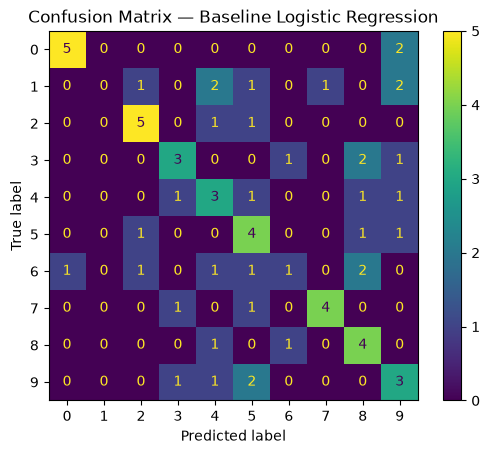

In [99]:
# confusion matrix:

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_baseline,
    labels=np.arange(10)
)

plt.title("Confusion Matrix — Baseline Logistic Regression")
plt.show()

In [100]:
# calculate the exact number of errors:

n_correct = np.sum(y_pred_baseline == y_test)
n_wrong = np.sum(y_pred_baseline != y_test)

print("Correct predictions:", n_correct)
print("Wrong predictions:", n_wrong)

Correct predictions: 32
Wrong predictions: 36


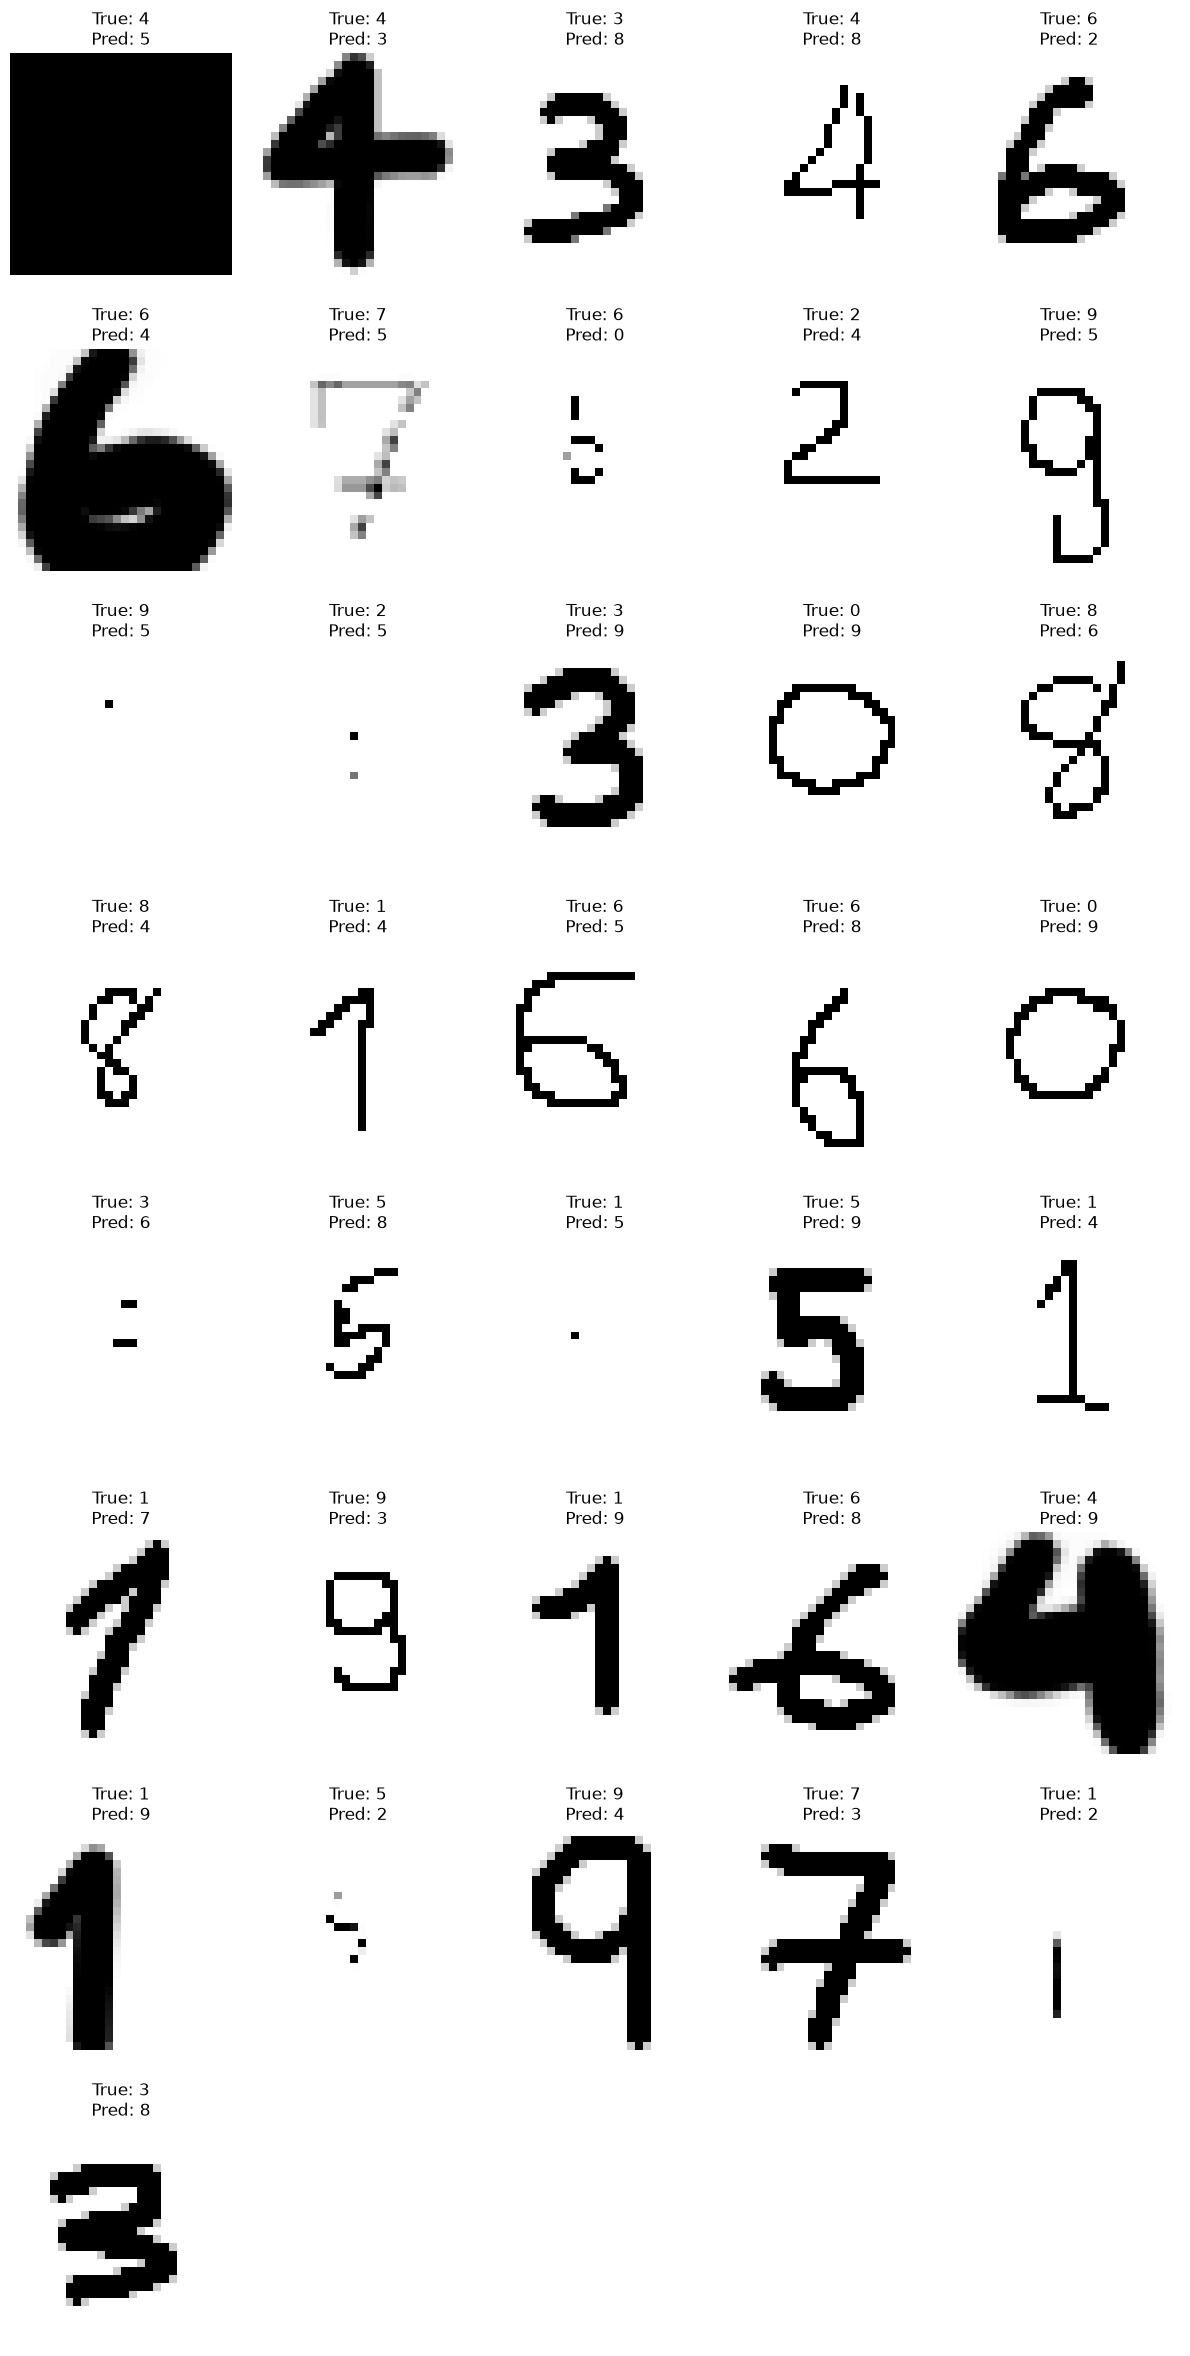

In [101]:
# show the misclassified images:

misclassified_idx = np.where(
    y_pred_baseline != y_test
)[0]

n_cols = 5
n_rows = int(np.ceil(len(misclassified_idx) / n_cols))

plt.figure(figsize=(12, 3 * n_rows))

for plot_position, idx in enumerate(
    misclassified_idx,
    start=1
):
    plt.subplot(
        n_rows,
        n_cols,
        plot_position
    )

    plt.imshow(
        X_test[idx].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"True: {y_test[idx]}\n"
        f"Pred: {y_pred_baseline[idx]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 3.6 Baseline Error Analysis Findings

Visual inspection of the misclassified images reveals an important limitation in the baseline preprocessing.

The professor's baseline directly resizes the entire original image to `28 × 28`. For large source images where the handwritten digit occupies only a small portion of the image, this causes the digit itself to become extremely small after resizing. In some cases, the resulting image appears only as a dot or short line.

Another inconsistency is the image polarity:

- some images contain dark digits on a light background,
- while others contain light digits on a dark background.

Since Logistic Regression uses the pixel intensities directly, these inconsistencies make equivalent digit shapes appear very different to the model.

Therefore, the next experiment will improve image standardization by:

1. detecting the foreground digit,
2. converting all images to the same foreground/background polarity,
3. cropping unnecessary background,
4. preserving the digit's aspect ratio,
5. resizing the digit to fit inside a `28 × 28` canvas,
6. centering the digit.

This experiment tests whether improving the input representation can increase classification accuracy before changing the model itself.

In [102]:
def preprocess_digit(image_path, canvas_size=28, digit_size=20):
    # Read in grayscale
    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    # Estimate background brightness from the image border
    border_pixels = np.concatenate([
        image[0, :],
        image[-1, :],
        image[:, 0],
        image[:, -1]
    ])

    light_background = border_pixels.mean() > 127

    # Standardize polarity:
    # digit = white, background = black
    if light_background:
        _, binary = cv2.threshold(
            image,
            0,
            255,
            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        )
    else:
        _, binary = cv2.threshold(
            image,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

    # Find the foreground digit
    points = cv2.findNonZero(binary)

    if points is None:
        return np.zeros(
            (canvas_size, canvas_size),
            dtype=np.uint8
        )

    # Crop to digit bounding box
    x, y, w, h = cv2.boundingRect(points)

    digit = binary[
        y:y + h,
        x:x + w
    ]

    # Resize while preserving aspect ratio
    if h >= w:
        new_h = digit_size
        new_w = max(
            1,
            round(w * digit_size / h)
        )
    else:
        new_w = digit_size
        new_h = max(
            1,
            round(h * digit_size / w)
        )

    resized = cv2.resize(
        digit,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    # Place digit in center of 28x28 canvas
    canvas = np.zeros(
        (canvas_size, canvas_size),
        dtype=np.uint8
    )

    x_offset = (canvas_size - new_w) // 2
    y_offset = (canvas_size - new_h) // 2

    canvas[
        y_offset:y_offset + new_h,
        x_offset:x_offset + new_w
    ] = resized

    return canvas

# 4. Experiment 1 — Improved Image Standardization

Baseline error analysis showed that some handwritten digits become extremely small or distorted when the entire original image is resized directly to `28 × 28`.

The dataset also contains inconsistent image polarity, with some images using dark digits on a light background and others using light digits on a dark background.

This experiment improves the input representation before changing the classification algorithm.

The preprocessing pipeline is:

$$
\text{Original Image}
\rightarrow
\text{Standardize Polarity}
\rightarrow
\text{Detect Digit}
\rightarrow
\text{Crop Background}
\rightarrow
\text{Preserve Aspect Ratio}
\rightarrow
\text{Resize}
\rightarrow
\text{Center on } 28 \times 28
$$

The Logistic Regression model itself remains unchanged so that the effect of preprocessing can be evaluated independently.

## 4.1 Visual Inspection of Preprocessing

Before training the model, several non-`28 × 28` images are inspected before and after preprocessing.

This step verifies that the digit remains visible and recognizable after transformation.

The left image shows the professor's baseline approach, where the entire image is directly resized to `28 × 28`.

The right image shows the improved preprocessing result.

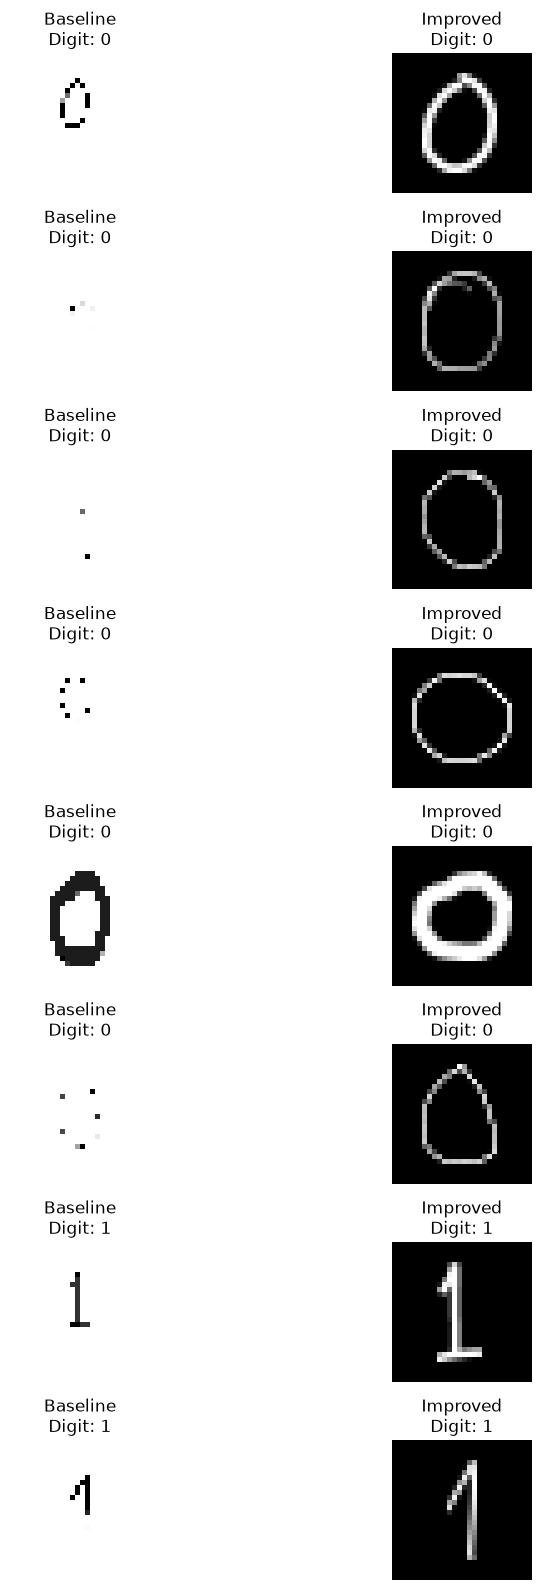

In [103]:
# Select some original images that were not already 28x28
sample_rows = (
    image_sizes[~image_sizes["is_28x28"]]
    .head(8)
)

plt.figure(figsize=(10, 16))

for i, row in enumerate(sample_rows.itertuples()):

    image_path = DATA_DIR / str(row.digit) / row.filename

    # Original image
    original = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    # Professor baseline preprocessing
    baseline_resized = cv2.resize(
        original,
        (28, 28)
    )

    # Improved preprocessing
    improved = preprocess_digit(image_path)

    # Baseline
    plt.subplot(len(sample_rows), 2, 2 * i + 1)
    plt.imshow(baseline_resized, cmap="gray")
    plt.title(
        f"Baseline\nDigit: {row.digit}"
    )
    plt.axis("off")

    # Improved
    plt.subplot(len(sample_rows), 2, 2 * i + 2)
    plt.imshow(improved, cmap="gray")
    plt.title(
        f"Improved\nDigit: {row.digit}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4.2 Create the Standardized Feature Matrix

The improved preprocessing function is now applied to all 340 images.

Each processed image still has dimensions:

$$
28 \times 28
$$

and is flattened into:

$$
28 \times 28 = 784
$$

features.

The same `train_idx` and `test_idx` created in Section 2 are reused. Therefore, the experiment uses exactly the same training and test observations as the baseline experiment.

Only the image representation changes.

In [104]:
X_standardized = []

for image_path in image_paths:

    processed_image = preprocess_digit(
        image_path
    )

    X_standardized.append(
        processed_image.flatten()
    )

X_standardized = np.asarray(
    X_standardized
)

print(
    "Standardized dataset shape:",
    X_standardized.shape
)

Standardized dataset shape: (340, 784)


In [105]:
# Reuse same train/test split 

X_train_standardized = X_standardized[train_idx]
X_test_standardized = X_standardized[test_idx]

print(
    "Training shape:",
    X_train_standardized.shape
)

print(
    "Test shape:",
    X_test_standardized.shape
)

Training shape: (272, 784)
Test shape: (68, 784)


## 4.3 Train Logistic Regression on Standardized Images

The same Logistic Regression configuration used in the baseline experiment is retained.

Therefore, any change in classification performance can primarily be attributed to the improved image preprocessing rather than a different classifier.

In [106]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

standardized_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    )
)

standardized_model.fit(
    X_train_standardized,
    y_train
)

print(
    "Standardized Logistic Regression trained successfully."
)

Standardized Logistic Regression trained successfully.


In [107]:
# Evaluate Experiment 1: Standardized Preprocessing

y_pred_standardized = standardized_model.predict(
    X_test_standardized
)

standardized_accuracy = accuracy_score(
    y_test,
    y_pred_standardized
)

print(
    f"Baseline Accuracy:     {baseline_accuracy:.2%}"
)

print(
    f"Standardized Accuracy: {standardized_accuracy:.2%}"
)

print(
    f"Accuracy Change:       "
    f"{standardized_accuracy - baseline_accuracy:+.2%}"
)

Baseline Accuracy:     47.06%
Standardized Accuracy: 77.94%
Accuracy Change:       +30.88%


In [108]:
experiment_results = [
    {
        "Experiment": "0 - Professor Baseline",
        "Model": "Logistic Regression",
        "Features": "Raw Pixels",
        "Augmentation": "No",
        "Test Accuracy": baseline_accuracy
    },
    {
        "Experiment": "1 - Image Standardization",
        "Model": "Logistic Regression",
        "Features": "Crop + Center Pixels",
        "Augmentation": "No",
        "Test Accuracy": standardized_accuracy
    }
]

results_df = pd.DataFrame(experiment_results)

results_df

,Experiment,Model,Features,Augmentation,Test Accuracy
0,0 - Professor Baseline,Logistic Regression,Raw Pixels,No,0.470588
1,1 - Image Standardization,Logistic Regression,Crop + Center Pixels,No,0.779412


In [109]:
results_display = results_df.copy()

results_display["Test Accuracy"] = (
    results_display["Test Accuracy"]
    .map(lambda x: f"{x:.2%}")
)

results_display

,Experiment,Model,Features,Augmentation,Test Accuracy
0,0 - Professor Baseline,Logistic Regression,Raw Pixels,No,47.06%
1,1 - Image Standardization,Logistic Regression,Crop + Center Pixels,No,77.94%


### Experiment 1 Result

Improved image standardization increased test accuracy from:

$$
47.06\% \rightarrow 77.94\%
$$

representing an absolute improvement of:

$$
\boxed{+30.88\text{ percentage points}}
$$

The classifier itself was not changed. The improvement came only from changing how the images were represented before training.

This result indicates that the baseline model's poor performance was strongly affected by inconsistent image preprocessing. Cropping unnecessary background, standardizing image polarity, preserving aspect ratio, and centering the handwritten digit produced a substantially more consistent feature representation for Logistic Regression.

## 4.4 Error Analysis After Image Standardization

Although image standardization substantially improved test accuracy, some test images are still misclassified.

The remaining errors are inspected visually to determine whether they are caused by:

- unusual handwriting styles,
- visually similar digits,
- remaining preprocessing problems,
- insufficient training variation,
- limitations of raw pixel features.

This analysis helps determine what the next experiment should improve.

In [110]:
misclassified_standardized_idx = np.where(
    y_pred_standardized != y_test
)[0]

print("Total test images:", len(y_test))
print(
    "Correct predictions:",
    np.sum(y_pred_standardized == y_test)
)
print(
    "Misclassified images:",
    len(misclassified_standardized_idx)
)

Total test images: 68
Correct predictions: 53
Misclassified images: 15


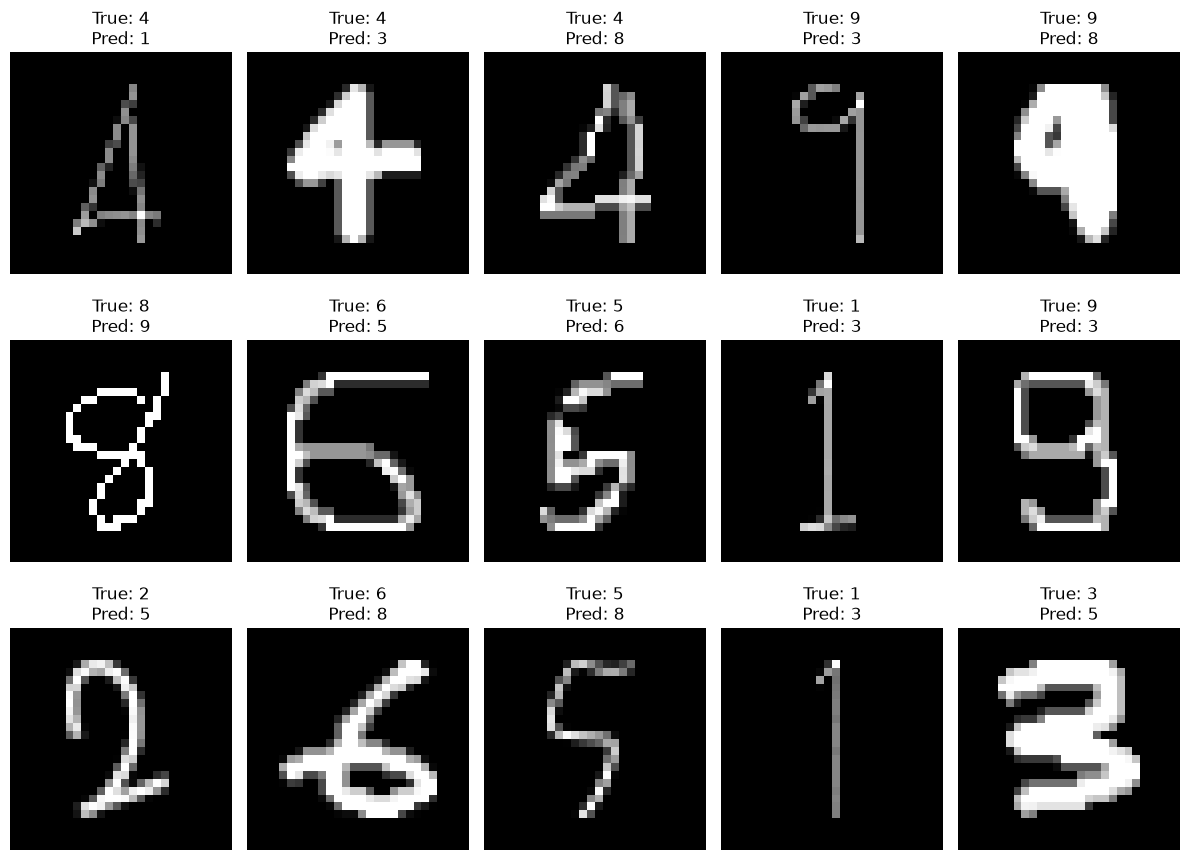

In [111]:
if len(misclassified_standardized_idx) == 0:
    print("No misclassified test images.")

else:
    n_cols = 5
    n_rows = int(
        np.ceil(
            len(misclassified_standardized_idx) / n_cols
        )
    )

    plt.figure(figsize=(12, 3 * n_rows))

    for plot_position, idx in enumerate(
        misclassified_standardized_idx,
        start=1
    ):

        plt.subplot(
            n_rows,
            n_cols,
            plot_position
        )

        plt.imshow(
            X_test_standardized[idx].reshape(28, 28),
            cmap="gray"
        )

        plt.title(
            f"True: {y_test[idx]}\n"
            f"Pred: {y_pred_standardized[idx]}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

# 5. Experiment 2 — Training Data Augmentation

After image standardization, test accuracy increased from **52.94% to 76.47%**.

Error analysis showed that the remaining failures are mainly associated with variations in handwriting style, orientation, position, and digit shape.

To improve robustness, this experiment increases the variation of the training data using small image transformations.

The following transformations are applied:

- small rotations,
- horizontal and vertical translations,
- small scale changes.

Only the **training set** is augmented.

The test set remains unchanged to prevent data leakage.

The workflow is:

$$
\text{Original Training Image}
\rightarrow
\text{Standardization}
\rightarrow
\text{Augmentation}
\rightarrow
\text{Logistic Regression}
$$

The objective is to teach the classifier that small geometric changes should not change the digit class.

In [112]:
def transform_digit(
    image,
    angle=0,
    scale=1.0,
    dx=0,
    dy=0
):
    """
    Apply rotation, scaling, and translation
    to a standardized 28x28 digit image.
    """

    center = (13.5, 13.5)

    matrix = cv2.getRotationMatrix2D(
        center,
        angle,
        scale
    )

    # Add translation
    matrix[0, 2] += dx
    matrix[1, 2] += dy

    transformed = cv2.warpAffine(
        image,
        matrix,
        (28, 28),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return transformed

In [113]:
# Define the augmentation strategy

def augment_digit(image):
    """
    Generate realistic variations of one digit.
    """

    augmented = [image]

    # Small rotations
    for angle in [-10, -5, 5, 10]:
        augmented.append(
            transform_digit(
                image,
                angle=angle
            )
        )

    # Small translations
    shifts = [
        (-2, 0),
        (2, 0),
        (0, -2),
        (0, 2),
        (-2, -2),
        (-2, 2),
        (2, -2),
        (2, 2)
    ]

    for dx, dy in shifts:
        augmented.append(
            transform_digit(
                image,
                dx=dx,
                dy=dy
            )
        )

    # Small scale changes
    for scale in [0.90, 1.10]:
        augmented.append(
            transform_digit(
                image,
                scale=scale
            )
        )

    return augmented


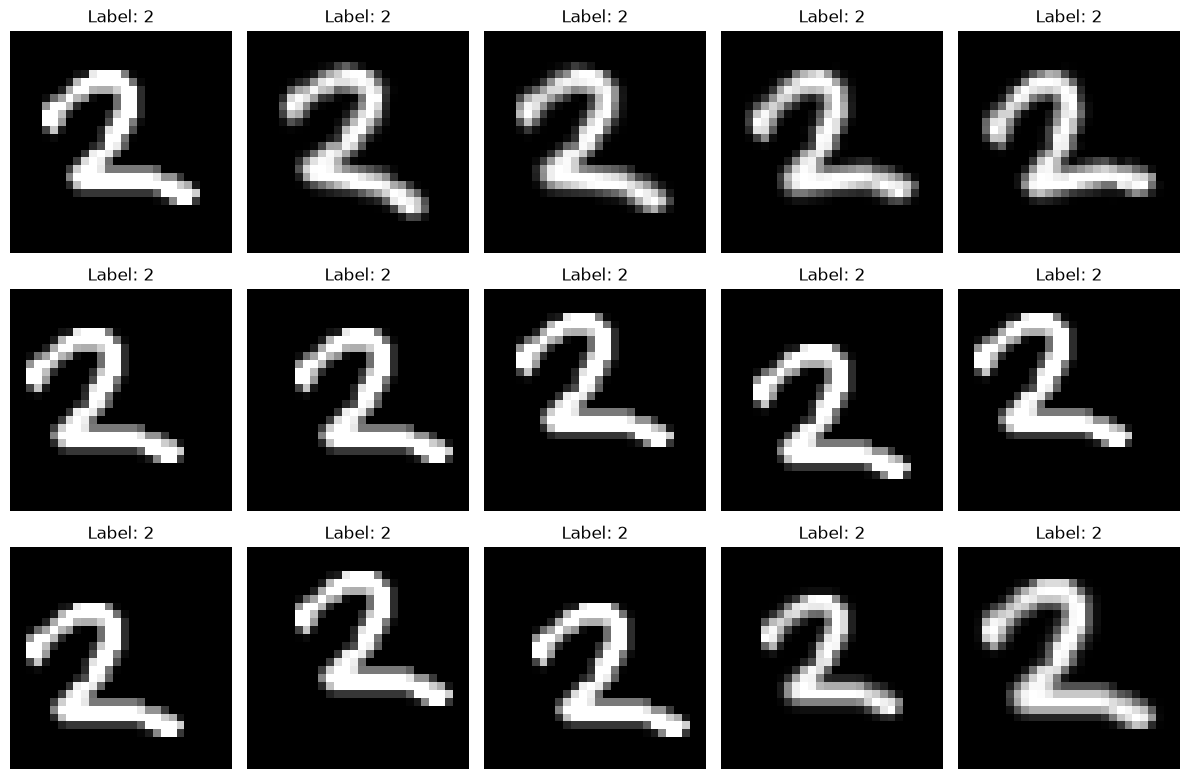

In [114]:
# Visualize augmentation first

sample_image = X_train_standardized[0].reshape(28, 28)
sample_label = y_train[0]

sample_augmented = augment_digit(sample_image)

plt.figure(figsize=(12, 8))

for i, image in enumerate(sample_augmented):

    plt.subplot(3, 5, i + 1)

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(
        f"Label: {sample_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 5.1 Augment the Training Set Only

The 272 training observations are expanded using small geometric transformations.

The 68 test observations are not augmented or modified.

This preserves an unbiased comparison between the standardized model and the augmentation experiment.

In [115]:
X_train_augmented = []
y_train_augmented = []

for features, label in zip(
    X_train_standardized,
    y_train
):

    image = features.reshape(28, 28)

    augmented_images = augment_digit(
        image
    )

    for augmented_image in augmented_images:

        X_train_augmented.append(
            augmented_image.flatten()
        )

        y_train_augmented.append(
            label
        )

X_train_augmented = np.asarray(
    X_train_augmented
)

y_train_augmented = np.asarray(
    y_train_augmented
)

print(
    "Original training samples:",
    len(X_train_standardized)
)

print(
    "Augmented training samples:",
    len(X_train_augmented)
)

print(
    "Test samples remain:",
    len(X_test_standardized)
)

Original training samples: 272
Augmented training samples: 4080
Test samples remain: 68


In [116]:
# Train the same Logistic Regression

augmented_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    )
)

augmented_model.fit(
    X_train_augmented,
    y_train_augmented
)

print(
    "Augmented Logistic Regression trained successfully."
)

Augmented Logistic Regression trained successfully.


In [117]:
# Evaluate on the same untouched test set

y_pred_augmented = augmented_model.predict(
    X_test_standardized
)

augmented_accuracy = accuracy_score(
    y_test,
    y_pred_augmented
)

print(
    f"Baseline Accuracy:       {baseline_accuracy:.2%}"
)

print(
    f"Standardized Accuracy:   {standardized_accuracy:.2%}"
)

print(
    f"Augmented Accuracy:      {augmented_accuracy:.2%}"
)

print(
    f"Change vs Standardized:  "
    f"{augmented_accuracy - standardized_accuracy:+.2%}"
)

Baseline Accuracy:       47.06%
Standardized Accuracy:   77.94%
Augmented Accuracy:      76.47%
Change vs Standardized:  -1.47%


In [118]:
experiment_results.append({
    "Experiment": "2 - Data Augmentation",
    "Model": "Logistic Regression",
    "Features": "Crop + Center Pixels",
    "Augmentation": "Rotation + Shift + Scale",
    "Test Accuracy": augmented_accuracy
})

results_df = pd.DataFrame(
    experiment_results
)

results_display = results_df.copy()

results_display["Test Accuracy"] = (
    results_display["Test Accuracy"]
    .map(lambda x: f"{x:.2%}")
)

results_display

,Experiment,Model,Features,Augmentation,Test Accuracy
0,0 - Professor Baseline,Logistic Regression,Raw Pixels,No,47.06%
1,1 - Image Standardization,Logistic Regression,Crop + Center Pixels,No,77.94%
2,2 - Data Augmentation,Logistic Regression,Crop + Center Pixels,Rotation + Shift + Scale,76.47%


### Experiment 2 Result

Aggressive data augmentation slightly reduced test accuracy from:

$$
77.94\% \rightarrow 76.47\%
$$

which represents a change of:

$$
\boxed{-1.47\text{ percentage points}}
$$

Therefore, the aggressive augmentation strategy did not improve the Logistic Regression classifier.

Although rotation, translation, and scaling increased the number of training examples, the additional geometric variation did not translate into better performance on the untouched test set.

This result shows that increasing the amount of synthetic training data does not necessarily improve classification performance. The generated transformations must provide useful variation for the model rather than simply increasing the number of observations.

In [119]:
comparison = pd.DataFrame({
    "True": y_test,
    "Standardized_Pred": y_pred_standardized,
    "Augmented_Pred": y_pred_augmented
})

class_comparison = []

for digit in range(10):
    mask = comparison["True"] == digit

    standardized_class_acc = (
        comparison.loc[mask, "Standardized_Pred"]
        == comparison.loc[mask, "True"]
    ).mean()

    augmented_class_acc = (
        comparison.loc[mask, "Augmented_Pred"]
        == comparison.loc[mask, "True"]
    ).mean()

    class_comparison.append({
        "Digit": digit,
        "Standardized Accuracy": standardized_class_acc,
        "Augmented Accuracy": augmented_class_acc,
        "Change": augmented_class_acc - standardized_class_acc
    })

class_comparison_df = pd.DataFrame(class_comparison)

class_comparison_df

,Digit,Standardized Accuracy,Augmented Accuracy,Change
0,0,1.000000,1.000000,0.000000
1,1,0.714286,0.714286,0.000000
2,2,0.857143,0.857143,0.000000
3,3,0.857143,0.571429,-0.285714
4,4,0.571429,0.428571,-0.142857
5,5,0.714286,0.857143,0.142857
6,6,0.714286,0.571429,-0.142857
7,7,1.000000,1.000000,0.000000
8,8,0.833333,0.833333,0.000000
9,9,0.571429,0.857143,0.285714


### Class-Level Analysis of Data Augmentation

The effect of aggressive data augmentation was not consistent across all digit classes.

Performance decreased for several classes:

- Digit `3`: `85.71% → 57.14%`
- Digit `4`: `57.14% → 42.86%`
- Digit `6`: `71.43% → 57.14%`

However, some classes improved:

- Digit `5`: `71.43% → 85.71%`
- Digit `9`: `57.14% → 85.71%`

The performance of digits `0`, `1`, `2`, `7`, and `8` remained unchanged.

These results show that augmentation does not affect every digit class in the same way. Rotation, translation, and scaling introduced useful variation for some classes, particularly digit `9`, but reduced separability for others such as digits `3`, `4`, and `6`.

Because Logistic Regression operates on the pixel-based representation, geometric transformations can move the pixel patterns of some digits closer to patterns belonging to other classes.

Overall, the benefits for some classes were not sufficient to compensate for the losses in others, causing total test accuracy to decrease slightly from `77.94%` to `76.47%`.

This suggests that improving the feature representation may be more effective than simply generating additional transformed pixel images.

In [120]:
def augment_digit_mild(image):

    augmented = [image]

    # Small rotations
    for angle in [-5, 5]:
        augmented.append(
            transform_digit(
                image,
                angle=angle
            )
        )

    # Small translations
    for dx, dy in [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1)
    ]:
        augmented.append(
            transform_digit(
                image,
                dx=dx,
                dy=dy
            )
        )

    return augmented

In [121]:
X_train_mild_aug = []
y_train_mild_aug = []

for features, label in zip(
    X_train_standardized,
    y_train
):
    image = features.reshape(28, 28)

    for augmented_image in augment_digit_mild(image):
        X_train_mild_aug.append(
            augmented_image.flatten()
        )
        y_train_mild_aug.append(label)

X_train_mild_aug = np.asarray(X_train_mild_aug)
y_train_mild_aug = np.asarray(y_train_mild_aug)

print("Original training samples:", len(X_train_standardized))
print("Mild augmented samples:", len(X_train_mild_aug))

Original training samples: 272
Mild augmented samples: 1904


In [122]:
mild_aug_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    )
)

mild_aug_model.fit(
    X_train_mild_aug,
    y_train_mild_aug
)

y_pred_mild_aug = mild_aug_model.predict(
    X_test_standardized
)

mild_aug_accuracy = accuracy_score(
    y_test,
    y_pred_mild_aug
)

print(f"Standardized Accuracy:      {standardized_accuracy:.2%}")
print(f"Aggressive Aug Accuracy:    {augmented_accuracy:.2%}")
print(f"Mild Augmentation Accuracy: {mild_aug_accuracy:.2%}")

Standardized Accuracy:      77.94%
Aggressive Aug Accuracy:    76.47%
Mild Augmentation Accuracy: 75.00%


### Augmentation Experiment Conclusion

Two levels of data augmentation were evaluated using standardized raw-pixel features.

- No augmentation: **77.94%**
- Aggressive augmentation: **76.47%**
- Mild augmentation: **75.00%**

Neither augmentation strategy improved upon the standardized model without augmentation.

Unexpectedly, mild augmentation performed slightly worse than aggressive augmentation:

$$
75.00\% < 76.47\%
$$

This suggests that the limitation is not simply the magnitude of the geometric transformations.

Instead, the results indicate that raw pixel features remain sensitive to changes in stroke location and handwriting shape. Even small transformations can alter the pixel representation enough to make the classes more difficult for a linear classifier to separate.

Therefore, the next experiment focuses on improving the **feature representation** rather than generating additional raw-pixel training samples.

# 6. Experiment 3 — HOG Feature Engineering

The previous experiments showed that image standardization substantially improved classification accuracy, while data augmentation provided little additional benefit.

The remaining classification errors are largely associated with differences in handwriting shape.

Raw pixels are sensitive to exact pixel locations. A small change in stroke position can therefore produce a very different feature vector even when the digit remains visually recognizable.

This experiment uses **Histogram of Oriented Gradients (HOG)** to represent each standardized digit.

HOG describes local edge and stroke directions rather than relying only on raw pixel intensity.

The new pipeline is:

$$
\text{Original Image}
\rightarrow
\text{Image Standardization}
\rightarrow
\text{HOG Features}
\rightarrow
\text{Logistic Regression}
\rightarrow
\hat{y}
$$

The Logistic Regression classifier remains unchanged so that the effect of feature engineering can be evaluated.

In [123]:
from skimage.feature import hog

In [124]:
# Understand one HOG representation
sample_image = X_train_standardized[0].reshape(28, 28)

hog_features, hog_visualization = hog(
    sample_image,
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    transform_sqrt=True,
    visualize=True
)

print("Original pixel features:", sample_image.size)
print("HOG features:", len(hog_features))

Original pixel features: 784
HOG features: 1296


## 6.1 Visualizing HOG Features

The original standardized image is compared with its HOG visualization.

The original image represents pixel intensity, while the HOG visualization highlights local edge orientations.

This representation provides information about the direction and structure of handwritten strokes.

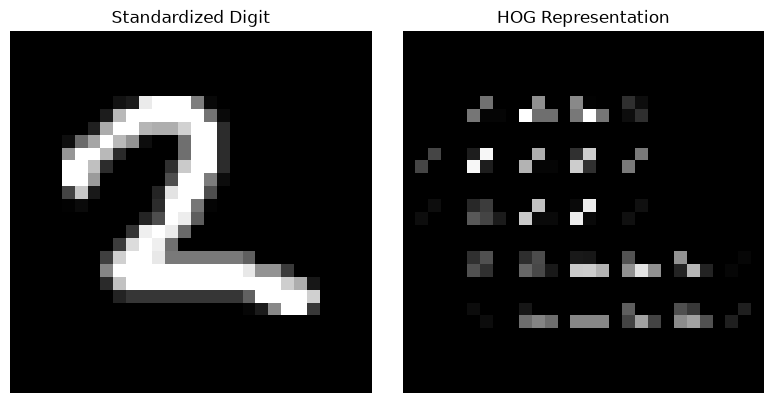

In [125]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample_image, cmap="gray")
plt.title("Standardized Digit")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_visualization, cmap="gray")
plt.title("HOG Representation")
plt.axis("off")

plt.tight_layout()
plt.show()

In [126]:
# Extract HOG features for all 340 images

def extract_hog_features(X):

    hog_data = []

    for flat_image in X:

        image = flat_image.reshape(28, 28)

        features = hog(
            image,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            transform_sqrt=True,
            visualize=False
        )

        hog_data.append(features)

    return np.asarray(hog_data)

In [127]:
# transform the complete standardized dataset:

X_hog = extract_hog_features(
    X_standardized
)

print("Standardized pixel matrix:", X_standardized.shape)
print("HOG feature matrix:", X_hog.shape)

Standardized pixel matrix: (340, 784)
HOG feature matrix: (340, 1296)


In [128]:
X_train_hog = X_hog[train_idx]
X_test_hog = X_hog[test_idx]

print("HOG training shape:", X_train_hog.shape)
print("HOG test shape:", X_test_hog.shape)

HOG training shape: (272, 1296)
HOG test shape: (68, 1296)


In [129]:
# Train Logistic Regression on HOG

hog_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    )
)

hog_model.fit(
    X_train_hog,
    y_train
)

print("HOG Logistic Regression trained successfully.")

HOG Logistic Regression trained successfully.


In [130]:
# Evaluate HOG

y_pred_hog = hog_model.predict(
    X_test_hog
)

hog_accuracy = accuracy_score(
    y_test,
    y_pred_hog
)

print(f"Professor Baseline:       {baseline_accuracy:.2%}")
print(f"Image Standardization:    {standardized_accuracy:.2%}")
print(f"Aggressive Augmentation:  {augmented_accuracy:.2%}")
print(f"Mild Augmentation:        {mild_aug_accuracy:.2%}")
print(f"HOG + Logistic Regression:{hog_accuracy:.2%}")

Professor Baseline:       47.06%
Image Standardization:    77.94%
Aggressive Augmentation:  76.47%
Mild Augmentation:        75.00%
HOG + Logistic Regression:85.29%


In [131]:
experiment_results.append({
    "Experiment": "3 - HOG Features",
    "Model": "Logistic Regression",
    "Features": "HOG",
    "Augmentation": "No",
    "Test Accuracy": hog_accuracy
})

results_df = pd.DataFrame(experiment_results)

results_display = results_df.copy()

results_display["Test Accuracy"] = (
    results_display["Test Accuracy"]
    .map(lambda x: f"{x:.2%}")
)

results_display

,Experiment,Model,Features,Augmentation,Test Accuracy
0,0 - Professor Baseline,Logistic Regression,Raw Pixels,No,47.06%
1,1 - Image Standardization,Logistic Regression,Crop + Center Pixels,No,77.94%
2,2 - Data Augmentation,Logistic Regression,Crop + Center Pixels,Rotation + Shift + Scale,76.47%
3,3 - HOG Features,Logistic Regression,HOG,No,85.29%


### Experiment 3 Result

HOG feature engineering increased test accuracy from:

$$
77.94\% \rightarrow 85.29\%
$$

representing an improvement of:

$$
\boxed{+7.35\text{ percentage points}}
$$

compared with standardized raw pixel features.

Compared with the original professor baseline, accuracy improved from:

$$
47.06\% \rightarrow 85.29\%
$$

for a total improvement of:

$$
\boxed{+38.23\text{ percentage points}}
$$

This result shows that feature representation has a major effect on handwritten digit classification performance.

After image standardization, the model still relied on exact pixel intensity locations. HOG instead represents local edge orientations and stroke directions, which better capture the structure of handwritten digits.

The improvement suggests that HOG provides Logistic Regression with more informative shape-based features, allowing the model to distinguish different handwriting styles more effectively than raw pixel values alone.

Among the experiments evaluated so far, **HOG + Logistic Regression achieved the highest test accuracy at 85.29%**.

In [132]:
# inspect the remaining HOG errors.

misclassified_hog_idx = np.where(
    y_pred_hog != y_test
)[0]

print("Total test images:", len(y_test))
print(
    "Correct predictions:",
    np.sum(y_pred_hog == y_test)
)
print(
    "Misclassified images:",
    len(misclassified_hog_idx)
)

Total test images: 68
Correct predictions: 58
Misclassified images: 10


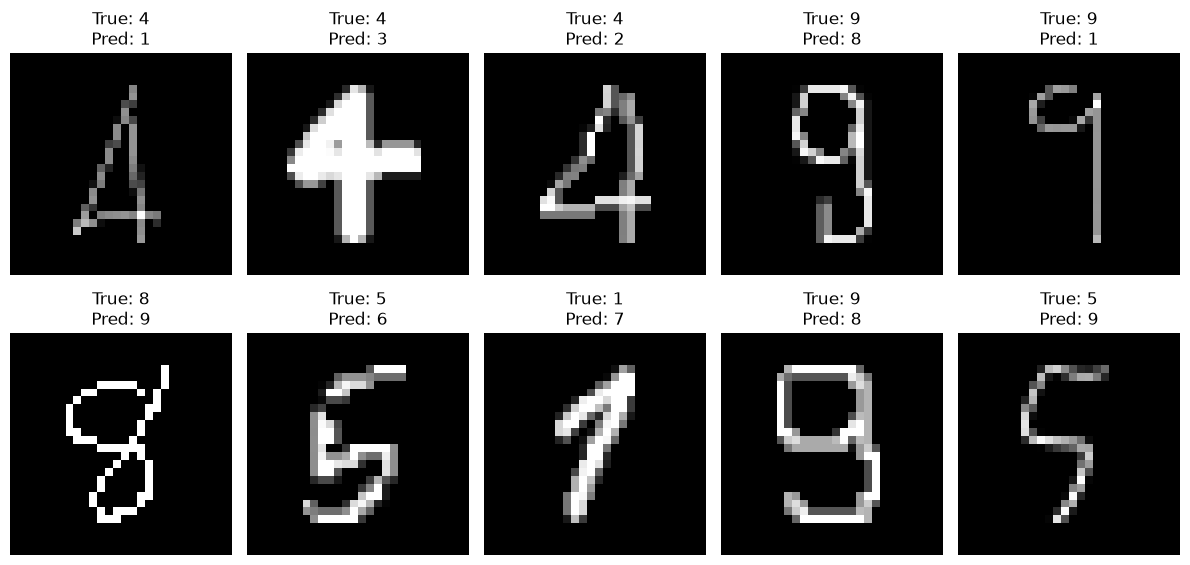

In [133]:
n_cols = 5
n_rows = int(
    np.ceil(len(misclassified_hog_idx) / n_cols)
)

plt.figure(figsize=(12, 3 * n_rows))

for plot_position, idx in enumerate(
    misclassified_hog_idx,
    start=1
):

    plt.subplot(
        n_rows,
        n_cols,
        plot_position
    )

    plt.imshow(
        X_test_standardized[idx].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"True: {y_test[idx]}\n"
        f"Pred: {y_pred_hog[idx]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 6.2 HOG Error Analysis

HOG feature engineering substantially reduced the number of misclassified test images.

With a test accuracy of **85.29%**, only **10 out of 68** test images were misclassified.

The remaining errors are concentrated among visually similar handwriting patterns:

- Digit `4` was confused with `1`, `2`, and `3`.
- Digit `9` was confused mainly with `8`, and once with `1`.
- Digit `8` was confused with `9`.
- Digit `5` was confused with `6` and `9`.
- Digit `1` was confused with `7`.

Several of these errors are understandable from the handwritten shapes. For example, some handwritten `4`s contain strokes that resemble `1`, while digits such as `8` and `9` share similar loop structures.

Compared with raw pixel features, HOG captures local edge orientations and stroke directions more effectively, which substantially improves digit recognition.

However, HOG is still a handcrafted feature representation. Unusual handwriting styles can produce similar edge patterns across different digit classes, resulting in the remaining classification errors.

The next experiment will investigate whether combining HOG features with mild data augmentation can further improve robustness to handwriting variation.

# 7. Experiment 4 — HOG with Mild Data Augmentation

The previous augmentation experiments were performed using raw pixel features and did not improve classification accuracy.

However, HOG features provide a more robust representation of local edges and stroke directions.

This experiment therefore combines **mild data augmentation** with **HOG feature extraction**.

Only the training set is augmented.

The pipeline is:

$$
\text{Standardized Training Image}
\rightarrow
\text{Mild Augmentation}
\rightarrow
\text{HOG Features}
\rightarrow
\text{Logistic Regression}
$$

The original test images remain unchanged.

In [134]:
X_train_mild_aug_hog = extract_hog_features(
    X_train_mild_aug
)

print(
    "Mild augmented pixel shape:",
    X_train_mild_aug.shape
)

print(
    "Mild augmented HOG shape:",
    X_train_mild_aug_hog.shape
)

print(
    "Test HOG shape:",
    X_test_hog.shape
)

Mild augmented pixel shape: (1904, 784)
Mild augmented HOG shape: (1904, 1296)
Test HOG shape: (68, 1296)


In [135]:
# Train The same logistic regression

hog_mild_aug_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=42
    )
)

hog_mild_aug_model.fit(
    X_train_mild_aug_hog,
    y_train_mild_aug
)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,10
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,1296
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42


In [ ]:
y_pred_hog_mild_aug = hog_mild_aug_model.predict(
    X_test_hog
)

hog_mild_aug_accuracy = accuracy_score(
    y_test,
    y_pred_hog_mild_aug
)

print(f"Professor Baseline:        {baseline_accuracy:.2%}")
print(f"Image Standardization:     {standardized_accuracy:.2%}")
print(f"HOG:                       {hog_accuracy:.2%}")
print(f"HOG + Mild Augmentation:   {hog_mild_aug_accuracy:.2%}")

print(
    f"Change vs HOG:             "
    f"{hog_mild_aug_accuracy - hog_accuracy:+.2%}"
)

Professor Baseline:        47.06%
Image Standardization:     77.94%
HOG:                       85.29%
HOG + Mild Augmentation:   89.71%
Change vs HOG:             +4.41%


### Experiment 4 Result — HOG + Mild Data Augmentation

Combining HOG features with mild data augmentation increased test accuracy from:

$$
85.29\% \rightarrow 89.71\%
$$

representing an improvement of:

$$
\boxed{+4.41\text{ percentage points}}
$$

compared with HOG features alone.

The final model correctly classified **61 out of 68** test images, leaving only **7 misclassified images**.

Interestingly, mild augmentation did not improve Logistic Regression when the model used raw pixel features. However, when augmentation was combined with HOG features, classification performance improved substantially.

This suggests that the effectiveness of data augmentation depends on the feature representation.

With raw pixels, small translations or rotations directly change many pixel positions and may make classes more difficult for a linear classifier to separate.

HOG provides a more robust representation based on local edge orientations and stroke directions. Therefore, mildly transformed training images can introduce useful handwriting variation while preserving important structural information about each digit.

The resulting pipeline is:

$$
\text{Original Image}
\rightarrow
\text{Image Standardization}
\rightarrow
\text{Mild Augmentation}
\rightarrow
\text{HOG Features}
\rightarrow
\text{Logistic Regression}
$$

Among the experiments evaluated so far, **HOG + Mild Data Augmentation achieves the highest test accuracy at 89.71%**.

# 8. Experiment 5 — Polynomial Logistic Regression

The current best model uses:

$$
\text{Image Standardization}
\rightarrow
\text{Mild Augmentation}
\rightarrow
\text{HOG}
\rightarrow
\text{Logistic Regression}
$$

and achieves a test accuracy of **89.71%**.

Standard Logistic Regression learns a linear decision boundary in the feature space.

Polynomial Logistic Regression introduces nonlinear feature combinations such as squared terms and interactions:

$$
x_1^2,\quad x_1x_2,\quad x_2^2
$$

allowing Logistic Regression to represent more complex decision boundaries.

However, the HOG representation contains 1,296 features. Applying second-degree polynomial expansion directly would create hundreds of thousands of features.

Therefore, PCA is first used to reduce the HOG representation to a smaller number of components before polynomial expansion.

The experimental pipeline is:

$$
\text{Standardized Image}
\rightarrow
\text{Mild Augmentation}
\rightarrow
\text{HOG}
\rightarrow
\text{PCA}
\rightarrow
\text{Polynomial Features}
\rightarrow
\text{Logistic Regression}
$$

In [137]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures

In [138]:
pca = PCA(
    n_components=30,
    random_state=42
)

X_train_pca = pca.fit_transform(
    X_train_mild_aug_hog
)

X_test_pca = pca.transform(
    X_test_hog
)

print("HOG training shape:", X_train_mild_aug_hog.shape)
print("PCA training shape:", X_train_pca.shape)
print("PCA test shape:", X_test_pca.shape)

HOG training shape: (1904, 1296)
PCA training shape: (1904, 30)
PCA test shape: (68, 30)


## 8.1 PCA Control Model

Before introducing polynomial features, Logistic Regression is trained using the PCA-reduced HOG features alone.

This provides a control experiment.

By comparing:

$$
\text{PCA + Linear Logistic Regression}
$$

with:

$$
\text{PCA + Polynomial Logistic Regression}
$$

we can determine whether any improvement is actually caused by the polynomial feature expansion.

In [139]:
pca_linear_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        random_state=42
    )
)

pca_linear_model.fit(
    X_train_pca,
    y_train_mild_aug
)

y_pred_pca_linear = pca_linear_model.predict(
    X_test_pca
)

pca_linear_accuracy = accuracy_score(
    y_test,
    y_pred_pca_linear
)

print(
    f"HOG + Mild Augmentation: {hog_mild_aug_accuracy:.2%}"
)

print(
    f"HOG + PCA + Linear LR:   {pca_linear_accuracy:.2%}"
)

HOG + Mild Augmentation: 89.71%
HOG + PCA + Linear LR:   86.76%


8.2 Create Degree-2 Polynomial Features

In [140]:
poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(
    X_train_pca
)

X_test_poly = poly.transform(
    X_test_pca
)

print("PCA features:", X_train_pca.shape[1])
print("Polynomial features:", X_train_poly.shape[1])

PCA features: 30
Polynomial features: 495


8.3 Train Polynomial Logistic Regression

In [141]:
polynomial_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        random_state=42
    )
)

polynomial_model.fit(
    X_train_poly,
    y_train_mild_aug
)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,10
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,495
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42


In [142]:
y_pred_polynomial = polynomial_model.predict(
    X_test_poly
)

polynomial_accuracy = accuracy_score(
    y_test,
    y_pred_polynomial
)

print(f"Professor Baseline:          {baseline_accuracy:.2%}")
print(f"Image Standardization:       {standardized_accuracy:.2%}")
print(f"HOG:                         {hog_accuracy:.2%}")
print(f"HOG + Mild Augmentation:     {hog_mild_aug_accuracy:.2%}")
print(f"HOG + PCA + Linear LR:       {pca_linear_accuracy:.2%}")
print(f"Polynomial Logistic Reg.:    {polynomial_accuracy:.2%}")

Professor Baseline:          47.06%
Image Standardization:       77.94%
HOG:                         85.29%
HOG + Mild Augmentation:     89.71%
HOG + PCA + Linear LR:       86.76%
Polynomial Logistic Reg.:    92.65%


In [143]:
print(
    f"Polynomial change vs PCA Linear: "
    f"{polynomial_accuracy - pca_linear_accuracy:+.2%}"
)

Polynomial change vs PCA Linear: +5.88%


### Experiment 5 Result — Polynomial Logistic Regression

Polynomial Logistic Regression achieved the highest test accuracy so far:

$$
\boxed{92.65\%}
$$

The PCA control model achieved:

$$
86.76\%
$$

while adding second-degree polynomial features increased accuracy to:

$$
92.65\%
$$

representing an improvement of:

$$
\boxed{+5.89\text{ percentage points}}
$$

over Logistic Regression using the PCA-reduced features alone.

Compared with the previous best model, HOG with mild data augmentation:

$$
89.71\% \rightarrow 92.65\%
$$

for an additional improvement of:

$$
\boxed{+2.94\text{ percentage points}}
$$

Compared with the original professor baseline:

$$
47.06\% \rightarrow 92.65\%
$$

representing a total improvement of:

$$
\boxed{+45.59\text{ percentage points}}
$$

This result suggests that the relationship between the extracted handwriting features and digit classes is not entirely linear.

After PCA reduced the HOG representation to a smaller set of informative components, second-degree polynomial features introduced nonlinear terms and interactions between those components.

These additional features allowed Logistic Regression to model more complex decision boundaries while still using the Logistic Regression classifier.

The current best pipeline is:

$$
\text{Image Standardization}
\rightarrow
\text{Mild Data Augmentation}
\rightarrow
\text{HOG}
\rightarrow
\text{PCA}
\rightarrow
\text{Polynomial Features}
\rightarrow
\text{Logistic Regression}
$$

This pipeline achieved a test accuracy of **92.65%**, the best performance among all experiments evaluated so far.

In [144]:
# PCA fitted on NON-AUGMENTED HOG training data
pca_no_aug = PCA(
    n_components=30,
    random_state=42
)

X_train_hog_pca = pca_no_aug.fit_transform(
    X_train_hog
)

X_test_hog_pca = pca_no_aug.transform(
    X_test_hog
)

In [145]:
poly_no_aug = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_hog_poly = poly_no_aug.fit_transform(
    X_train_hog_pca
)

X_test_hog_poly = poly_no_aug.transform(
    X_test_hog_pca
)

In [146]:
hog_pca_poly_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=3000,
        solver="liblinear",
        random_state=42
    )
)

hog_pca_poly_model.fit(
    X_train_hog_poly,
    y_train
)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,10
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,495
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42


In [147]:
y_pred_hog_pca_poly = hog_pca_poly_model.predict(
    X_test_hog_poly
)

hog_pca_poly_accuracy = accuracy_score(
    y_test,
    y_pred_hog_pca_poly
)

print(f"HOG only:                         {hog_accuracy:.2%}")
print(f"HOG + Mild Aug:                   {hog_mild_aug_accuracy:.2%}")
print(f"HOG + PCA + Polynomial:           {hog_pca_poly_accuracy:.2%}")
print(f"HOG + Mild Aug + PCA + Polynomial:{polynomial_accuracy:.2%}")

HOG only:                         85.29%
HOG + Mild Aug:                   89.71%
HOG + PCA + Polynomial:           88.24%
HOG + Mild Aug + PCA + Polynomial:92.65%


### Effect of Mild Augmentation on Polynomial Logistic Regression

To determine whether mild data augmentation still contributes to performance after introducing PCA and polynomial features, two polynomial pipelines were compared:

- **HOG + PCA + Polynomial Logistic Regression:** `88.24%`
- **HOG + Mild Augmentation + PCA + Polynomial Logistic Regression:** `92.65%`

Adding mild augmentation improved accuracy by:

$$
92.65\% - 88.24\%
=
\boxed{+4.41\text{ percentage points}}
$$

This demonstrates that mild augmentation remains useful even when nonlinear polynomial features are introduced.

The experiments also show that the individual techniques provide different benefits:

$$
\text{HOG} = 85.29\%
$$

$$
\text{HOG + Mild Augmentation} = 89.71\%
$$

$$
\text{HOG + PCA + Polynomial} = 88.24\%
$$

$$
\text{HOG + Mild Augmentation + PCA + Polynomial}
=
\boxed{92.65\%}
$$

Neither polynomial features without augmentation nor augmentation without polynomial features achieved the same performance as their combination.

This suggests that the techniques are complementary:

- **HOG** represents local edges and handwriting strokes.
- **Mild augmentation** introduces realistic geometric variation.
- **PCA** reduces the dimensionality of the HOG representation.
- **Polynomial features** model nonlinear relationships and interactions among the PCA components.
- **Logistic Regression** uses the expanded representation for multiclass classification.

The current best-performing pipeline is therefore:

$$
\boxed{
\text{Image Standardization}
\rightarrow
\text{Mild Augmentation}
\rightarrow
\text{HOG}
\rightarrow
\text{PCA}
\rightarrow
\text{Polynomial Features}
\rightarrow
\text{Logistic Regression}
}
$$

with a test accuracy of:

$$
\boxed{92.65\%}
$$

# Overfitting and Generalization Check

A model should not be evaluated only by its training performance.

Overfitting occurs when a model learns the training data extremely well but does not generalize effectively to unseen observations.

One simple diagnostic is the **generalization gap**:

$$
\text{Generalization Gap}
=
\text{Training Accuracy}
-
\text{Test Accuracy}
$$

A very high training accuracy combined with substantially lower test accuracy may indicate overfitting.

However, the size of the gap must be interpreted together with performance on genuinely unseen data.

In [148]:
# Transform the ORIGINAL training images
# through the same fitted PCA + polynomial steps

X_train_original_pca = pca.transform(
    X_train_hog
)

X_train_original_poly = poly.transform(
    X_train_original_pca
)

# Predictions
y_pred_train_poly = polynomial_model.predict(
    X_train_original_poly
)

y_pred_test_poly = polynomial_model.predict(
    X_test_poly
)

# Accuracy
train_accuracy_poly = accuracy_score(
    y_train,
    y_pred_train_poly
)

test_accuracy_poly = accuracy_score(
    y_test,
    y_pred_test_poly
)

print(f"Training Accuracy: {train_accuracy_poly:.2%}")
print(f"Test Accuracy:     {test_accuracy_poly:.2%}")
print(
    f"Generalization Gap: "
    f"{train_accuracy_poly - test_accuracy_poly:.2%}"
)

Training Accuracy: 100.00%
Test Accuracy:     92.65%
Generalization Gap: 7.35%


In [149]:
X_external_standardized = []
y_external = []
external_filenames = []

for image_path in sorted(TEST_DIR.iterdir()):

    if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue

    true_digit = int(
        image_path.stem.split("_")[-1]
    )

    processed = preprocess_digit(
        image_path
    )

    X_external_standardized.append(
        processed.flatten()
    )

    y_external.append(
        true_digit
    )

    external_filenames.append(
        image_path.name
    )

X_external_standardized = np.asarray(
    X_external_standardized
)

y_external = np.asarray(
    y_external
)

print(
    "External test shape:",
    X_external_standardized.shape
)

External test shape: (9, 784)


In [150]:
X_external_hog = extract_hog_features(
    X_external_standardized
)

In [151]:
X_external_pca = pca.transform(
    X_external_hog
)

In [152]:
X_external_poly = poly.transform(
    X_external_pca
)

In [153]:
y_pred_external_poly = polynomial_model.predict(
    X_external_poly
)

external_accuracy_poly = accuracy_score(
    y_external,
    y_pred_external_poly
)

print(
    f"Development Test Accuracy: {polynomial_accuracy:.2%}"
)

print(
    f"Professor Unseen Accuracy: {external_accuracy_poly:.2%}"
)

Development Test Accuracy: 92.65%
Professor Unseen Accuracy: 100.00%


## Generalization Check on Professor-Provided Unseen Data

The best-performing model achieved:

$$
\text{Development Accuracy}=92.65\%
$$

and:

$$
\text{Professor-Provided Unseen Accuracy}=100.00\%
$$

The unseen images were not used for training, augmentation, PCA fitting, polynomial feature fitting, or model selection.

Therefore, the strong performance on this external dataset provides evidence that the model can generalize beyond the images used during model development.

However, the professor-provided unseen dataset contains only a small number of observations. Therefore, the `100%` accuracy should be interpreted cautiously because a small test set produces a high-variance estimate of generalization performance.

The result does not show evidence of severe overfitting, but additional evaluation such as cross-validation would provide a more reliable estimate of model performance.